In [ ]:
%cd ../..
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
%pip install deface

In [2]:
import cv2
import numpy as np
import tempfile
import subprocess
from pathlib import Path

def extract_k_frames(video_path: str, k: int, start_time: float = None, end_time: float = None):
    """Extract k evenly spaced frames from video as np.ndarray list.
    If start_time or end_time (in seconds) are provided, extract frames from that time range;
    otherwise use the entire video.
    """
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count == 0:
        cap.release()
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0  # fallback fps if unavailable

    # convert times to frame indices
    if start_time is None:
        start_frame = 0
    else:
        start_frame = int(max(0, round(start_time * fps)))

    if end_time is None:
        end_frame = frame_count - 1
    else:
        end_frame = int(min(frame_count - 1, round(end_time * fps)))

    # ensure valid range
    if end_frame < start_frame:
        start_frame, end_frame = 0, frame_count - 1

    indices = np.linspace(start_frame, end_frame, min(k, max(1, end_frame - start_frame + 1)), dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    cap.release()
    return frames

def deface_frame(
    frame: np.ndarray,
    *,
    mosaic_size: int = 30,   # width in pixels of the mosaic squares
    boxes: bool = False,     # True -> rectangular mask; False -> ellipse
    thresh: float = 0.6,     # detection threshold
    mask_scale: float = 0.95  # expand/contract face mask
) -> np.ndarray:
    """Pixelate (mosaic) faces in a single frame via the `deface` CLI."""
    import tempfile, subprocess, cv2
    from pathlib import Path

    with tempfile.TemporaryDirectory() as tmpdir:
        input_path = Path(tmpdir) / "frame.jpg"
        output_path = Path(tmpdir) / "frame_defaced.jpg"
        cv2.imwrite(str(input_path), frame)

        cmd = [
            "deface",
            str(input_path),
            "--output", str(output_path),
            "--replacewith", "mosaic",
            "--mosaicsize", str(mosaic_size),
            "--thresh", str(thresh),
            "--mask-scale", str(mask_scale),
        ]
        if boxes:
            cmd.append("--boxes")

        subprocess.run(cmd, check=True)
        return cv2.imread(str(output_path))

def deface_video_frames(video_path: str, k: int, start_time: float = None, end_time: float = None):
    """Extract K frames from an optional time range and deface them."""
    frames = extract_k_frames(video_path, k, start_time=start_time, end_time=end_time)
    defaced_frames = [deface_frame(f) for f in frames]
    return defaced_frames


In [3]:
import numpy as np
import cv2

def _draw_rounded_rect(img, x, y, w, h, r, color):
    """Filled rounded rectangle on an RGB image using OpenCV primitives."""
    r = max(0, min(r, min(w, h)//2))
    x2, y2 = x + w, y + h
    # center rect (without corners)
    cv2.rectangle(img, (x + r, y), (x2 - r, y2), color, -1)
    cv2.rectangle(img, (x, y + r), (x2, y2 - r), color, -1)
    # corners
    cv2.circle(img, (x + r, y + r), r, color, -1)
    cv2.circle(img, (x2 - r, y + r), r, color, -1)
    cv2.circle(img, (x + r, y2 - r), r, color, -1)
    cv2.circle(img, (x2 - r, y2 - r), r, color, -1)


def make_film_strip(
    frames,
    target_height: int = 240,
    spacing: int = 8,             # black spacing between frames
    side_border: int = 16,         # left/right black border
    top_bottom_border: int = 32,   # top/bottom black border height
    notch_width: int = 12,         # white notch size
    notch_height: int = 6,
    notch_radius: int = 2,         # slight rounding
    notch_period: int = 36,        # distance between successive notches
    *,
    bboxes=None,                   # NEW: list of per-frame (x,y,w,h) or None
    global_bbox=None,              # NEW: (x,y,w,h) applied to all frames if set
    alpha: float = 1.0,            # NEW: contrast (1.0 = no change)
    beta: float = 0.0,             # NEW: brightness offset in [−255, 255]
    gamma: float = 1.0             # NEW: gamma correction (1.0 = no change)
) -> np.ndarray:
    """
    Build a horizontal film strip from a list of frames (np.ndarray).
    Returns an RGB numpy image.

    Args:
        bboxes: Optional list of (x, y, w, h) per frame, or None.
        global_bbox: Optional (x, y, w, h) applied to all frames if provided.
        alpha: Contrast scale (used by cv2.convertScaleAbs). 1.0 = no change.
        beta: Brightness shift (used by cv2.convertScaleAbs). 0.0 = no change.
        gamma: Gamma correction. 1.0 = no change. (>1 darkens midtones, <1 brightens).
    """
    frames = [f for f in frames if f is not None]
    if not frames:
        raise ValueError("No frames provided")

    # NEW: basic validation for per-frame bboxes length
    if bboxes is not None and len(bboxes) != len(frames):  # NEW
        raise ValueError("bboxes length must match frames length")  # NEW

    def _safe_crop(img, bbox):  # NEW
        if bbox is None:
            return img
        x, y, w, h = map(int, bbox)
        H, W = img.shape[:2]
        x0 = max(0, x)
        y0 = max(0, y)
        x1 = min(W, x + w)
        y1 = min(H, y + h)
        if x1 <= x0 or y1 <= y0:
            return img  # fallback if bbox is invalid after clipping
        return img[y0:y1, x0:x1]

    def _adjust(img):  # NEW
        # Contrast/Brightness
        out = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        # Gamma correction (apply in float, then back to uint8)
        if gamma != 1.0:
            f = out.astype(np.float32) / 255.0
            f = np.power(f, 1.0 / float(gamma))
            out = np.clip(f * 255.0, 0, 255).astype(np.uint8)
        return out

    # Convert frames to RGB, optional crop, adjust, and resize to target_height
    rgb_frames = []
    for i, f in enumerate(frames):
        if f.ndim != 3 or f.shape[2] != 3:
            raise ValueError("Each frame must be HxWx3")

        # NEW: choose bbox priority: per-frame > global > None
        bbox = bboxes[i] if bboxes is not None else global_bbox  # NEW
        if bbox is not None:                                      # NEW
            f = _safe_crop(f, bbox)                              # NEW

        # Assume BGR input -> convert to RGB
        frgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)

        # NEW: apply contrast/brightness/gamma in RGB space
        frgb = _adjust(frgb)                                     # NEW

        h, w = frgb.shape[:2]
        new_w = int(round(w * (target_height / float(h))))
        frgb = cv2.resize(frgb, (new_w, target_height), interpolation=cv2.INTER_AREA)
        rgb_frames.append(frgb)

    # Compute canvas size
    widths = [im.shape[1] for im in rgb_frames]
    total_width = side_border + sum(widths) + spacing * (len(rgb_frames) - 1) + side_border
    total_height = top_bottom_border + target_height + top_bottom_border

    canvas = np.zeros((total_height, total_width, 3), dtype=np.uint8)  # black background

    # Paste frames
    x = side_border
    y = top_bottom_border
    for im in rgb_frames:
        h, w = im.shape[:2]
        canvas[y:y+h, x:x+w] = im
        x += w + spacing

    # Draw white rounded "perforation" notches across top and bottom borders
    white = (255, 255, 255)
    # Top row notches
    top_y = (top_bottom_border - notch_height) // 2
    # Bottom row notches
    bottom_y = top_bottom_border + target_height + (top_bottom_border - notch_height) // 2

    # Start a bit in from the left border so notches don't touch edges
    start_x = side_border + (notch_period // 2)
    end_x = total_width - side_border - notch_width

    cur = start_x
    while cur <= end_x:
        _draw_rounded_rect(canvas, cur, top_y, notch_width, notch_height, notch_radius, white)
        _draw_rounded_rect(canvas, cur, bottom_y, notch_width, notch_height, notch_radius, white)
        cur += notch_period

    return canvas

In [4]:
import math
import html
import io
from typing import List, Dict, Tuple, Optional, Union, Literal

import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont


# ----------------------------
# Shared helpers
# ----------------------------
_DEFAULT_PALETTE: List[Tuple[int, int, int]] = [
    (153, 153, 153),  # dull gray
    (0, 158, 115),    # stable/calm bluish green
    (230, 159, 0),    # orange
    (86, 180, 233),   # sky blue
    (204, 121, 167),  # purple
]

def _rgb_hex(rgb: Tuple[int, int, int]) -> str:
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def _infer_actions_in_order(label_segments: List[Dict]) -> List[str]:
    seen, order = set(), []
    for s in label_segments:
        a = s["action"]
        if a not in seen:
            seen.add(a)
            order.append(a)
    return order

def _ensure_color_map(actions_in_order: List[str],
                      color_map: Optional[Dict[str, Tuple[int, int, int]]]) -> Dict[str, Tuple[int, int, int]]:
    if color_map is None:
        return {a: _DEFAULT_PALETTE[i % len(_DEFAULT_PALETTE)] for i, a in enumerate(actions_in_order)}
    # validate provided map
    for a in actions_in_order:
        if a not in color_map:
            raise KeyError(f"'{a}' missing from color_map")
        r, g, b = color_map[a]
        for c in (r, g, b):
            if not (isinstance(c, int) and 0 <= c <= 255):
                raise ValueError(f"Invalid RGB value {color_map[a]} for '{a}'")
    return color_map

def _grid_for_n(n: int, preferred_columns: Optional[int]) -> Tuple[int, int]:
    """Return (n_cols, n_rows) using simple auto rule if columns is None."""
    n_cols = (1 if n <= 8 else 2) if preferred_columns is None else max(1, int(preferred_columns))
    n_rows = math.ceil(n / n_cols)
    return n_cols, n_rows


import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

def plot_color_map(color_map, box_size=0.5, font_size=24):
    """
    Make a simple vector-graphic legend from a color_map: Dict[label, color].
    Black background, white monospace text.
    Returns a matplotlib Figure.
    """
    labels = list(color_map.keys())
    n = len(labels)

    fig_h = max(1.0, 0.6 * n)
    fig, ax = plt.subplots(figsize=(2.1, fig_h))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.set_axis_off()

    for i, label in enumerate(labels):
        y = n - 1 - i  # draw from top to bottom
        color = np.array(color_map[label]) / 255.0
        ax.add_patch(Rectangle((0, y), box_size, box_size, color=color))
        ax.text(
            box_size + 0.2, y + box_size / 2,
            label,
            va="center", ha="left",
            fontsize=font_size,
            family="monospace",
            color="white"
        )

    ax.set_xlim(0, box_size + 1)
    ax.set_ylim(0, n)
    plt.tight_layout(pad=0.2)
    return fig


# ----------------------------
# Bar + raster legend (RGBA)
# ----------------------------
def make_action_bar_and_legend(
    label_segments: List[Dict],
    actions_in_order: Optional[List[str]],   # stays immediately after label_segments
    width: int,
    height: int = 24,
    color_map: Optional[Dict[str, Tuple[int, int, int]]] = None,
    *,
    draw_separators: bool = True,               # 1px separators between segments
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      bar_rgb   : HxWx3 uint8 (timeline color bar)
      legend_rgba: HxWx4 uint8 (transparent background)
    """
    if not label_segments:
        raise ValueError("No label_segments provided")

    # Timeline total
    ends = [s["start_time"] + s["duration"] for s in label_segments]
    total = max(ends)
    if total <= 0:
        raise ValueError("Total duration must be positive")

    # Actions + colors
    if actions_in_order is None:
        actions_in_order = _infer_actions_in_order(label_segments)
    if not actions_in_order:
        raise ValueError("actions_in_order is empty")
    color_map = _ensure_color_map(actions_in_order, color_map)

    # --- Build the bar (RGB) ---
    bar = np.zeros((height, width, 3), dtype=np.uint8)  # black background
    for s in label_segments:
        a = s["action"]
        c = color_map[a]
        x0 = int(round((s["start_time"] / total) * width))
        x1 = int(round(((s["start_time"] + s["duration"]) / total) * width))
        x0 = max(0, min(width - 1, x0))
        x1 = max(0, min(width, x1))
        if x1 <= x0:
            x1 = min(width, x0 + 1)
        bar[:, x0:x1, :] = c

    if draw_separators:
        for s_prev, s_next in zip(label_segments, label_segments[1:]):
            cut = int(round(((s_prev["start_time"] + s_prev["duration"]) / total) * width))
            if 0 <= cut < width:
                bar[:, cut:cut+1, :] = 0

    # --- Build the legend (RGBA, neat text with PIL + supersampling) ---
    legend = plot_color_map(color_map)

    return bar, legend


In [5]:
from data.utils_strokerehab import PrimitiveLabelUtils

def create_primitives_film_strip(video_path: str, label_path: str, bboxes=None, global_bbox=None, alpha=1.0, beta=0.0, gamma=1.0):

    defaced = deface_video_frames(video_path, k=6)
    print(f"Defaced {len(defaced)} frames of shape {[f.shape for f in defaced if f is not None]}")
    film = make_film_strip(defaced, bboxes=bboxes, global_bbox=global_bbox, alpha=alpha, beta=beta, gamma=gamma)
    film_image = Image.fromarray(film)

    segments = PrimitiveLabelUtils.convert_labels_to_action_sequence(label_path)
    actions_in_order = ['idle', 'reach', 'transport', 'reposition', 'stabilize']
    bar, legend = make_action_bar_and_legend(segments, actions_in_order, width=film.shape[1])
    bar_image = Image.fromarray(bar)

    buf = io.BytesIO()
    legend.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    legend_img = Image.open(buf)
    if legend_img.mode in ("RGBA", "LA"):
        bg = Image.new("RGB", legend_img.size, "white")
        bg.paste(legend_img, mask=legend_img.split()[-1])
        legend_img = bg
    else:
        legend_img = legend_img.convert("RGB")

    # Stack film and bar vertically (same width)
    film_bar = Image.new("RGB", (film_image.width, film_image.height + bar_image.height))
    film_bar.paste(film_image, (0, 0))
    film_bar.paste(bar_image, (0, film_image.height))

    # Resize legend to match combined height (keep aspect ratio)
    target_h = film_bar.height
    new_w = int(legend_img.width * target_h / legend_img.height)
    legend_resized = legend_img.resize((new_w, target_h), Image.LANCZOS)

    # 4) Concatenate: (film+bar) on the left, legend on the right
    final_image = Image.new("RGB", (film_bar.width + legend_resized.width, target_h))
    final_image.paste(film_bar, (0, 0))
    final_image.paste(legend_resized, (film_bar.width, 0))
    return final_image


# Object Bias: Combing -> RTT

Input:  /tmp/tmpseds8_3z/frame.jpg
Output: /tmp/tmpseds8_3z/frame_defaced.jpg
Input:  /tmp/tmp309ebhew/frame.jpg
Output: /tmp/tmp309ebhew/frame_defaced.jpg
Input:  /tmp/tmptb8kmlrg/frame.jpg
Output: /tmp/tmptb8kmlrg/frame_defaced.jpg
Input:  /tmp/tmpks_0ssj_/frame.jpg
Output: /tmp/tmpks_0ssj_/frame_defaced.jpg
(704, 1088, 3)


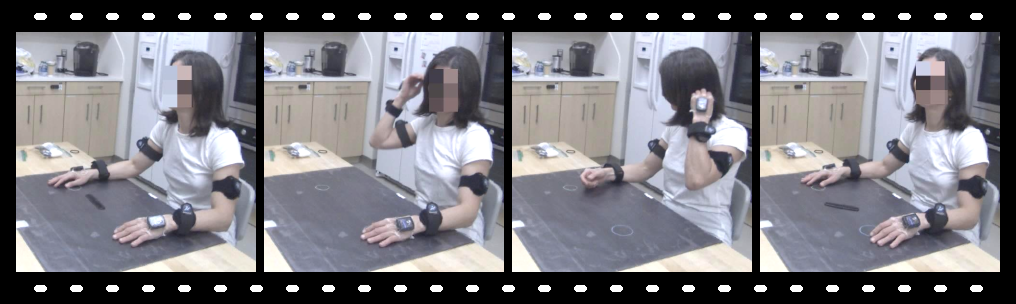

In [ ]:
video_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00022/C00022_combing1_1.mkv"
defaced = deface_video_frames(video_path, k=4)
print(defaced[0].shape)
film_strip = make_film_strip(defaced, global_bbox=(400, 200, 500, 500), alpha=1.2, beta=0  )  #, alpha=1.2, beta=15, gamma=1.4)
Image.fromarray(film_strip)

# Object Bias: What is the subject twisting?

In [ ]:
from tools.vqa.qwen2_5_vl import Qwen2_5_VL_VQA
vlm = Qwen2_5_VL_VQA(
    pretrained="Qwen/Qwen2.5-VL-32B-Instruct",
    device="cpu",
    device_map=None,
    use_cache=True,
)

/gpfs/scratch/vhl2022/miniconda3/envs/cvfm4rehab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing Qwen2_5_VL_VQA...
Using device: cpu
Model kwargs: {'pretrained_model_name_or_path': 'Qwen/Qwen2.5-VL-32B-Instruct', 'torch_dtype': torch.float32, 'low_cpu_mem_usage': False}
Loading model Qwen/Qwen2.5-VL-32B-Instruct...


Loading checkpoint shards: 100%|██████████| 18/18 [01:37<00:00,  5.41s/it]


Model loaded.
Model config: Qwen2_5_VLConfig {
  "architectures": [
    "Qwen2_5_VLForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 5120,
  "image_token_id": 151655,
  "initializer_range": 0.02,
  "intermediate_size": 27648,
  "max_position_embeddings": 128000,
  "max_window_layers": 64,
  "model_type": "qwen2_5_vl",
  "num_attention_heads": 40,
  "num_hidden_layers": 64,
  "num_key_value_heads": 8,
  "pad_token_id": 151643,
  "rms_norm_eps": 1e-06,
  "rope_scaling": {
    "mrope_section": [
      16,
      24,
      24
    ],
    "rope_type": "default",
    "type": "default"
  },
  "rope_theta": 1000000.0,
  "sliding_window": 32768,
  "text_config": {
    "architectures": [
      "Qwen2_5_VLForConditionalGeneration"
    ],
    "attention_dropout": 0.0,
    "eos_token_id": 151645,
    "hidden_act": "silu",
    "hidden_size": 5120,
    "image_token_id": null,
    "initializer_range": 0.02,
    "intermediate_siz

In [8]:
import cv2
import numpy as np

def load_frames_rgb(video_path, start_time=None, end_time=None, num_frames_to_extract=8):
    """
    Loads RGB frames from a video, optionally within a specified time range,
    and samples a specific number of frames if requested.

    :param video_path: Path to the video file.
    :param start_time: Start time (in seconds) for frame extraction.
    :param end_time: End time (in seconds) for frame extraction.
    :param num_frames_to_extract: The total number of frames to sample and return
                                  from the specified segment. If None, all frames
                                  in the segment are returned.
    :return: A numpy array of RGB frames, or an empty array if no frames were read.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return np.empty((0,))

    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 1. Determine the start and end frame indices
    s = 0 if start_time is None else int(start_time * fps)
    e = (n - 1) if end_time is None else int(end_time * fps)
    
    # Ensure indices are within valid range [0, n-1]
    s, e = max(0, s), min(n - 1, e)

    # Calculate the total number of frames in the selected segment
    total_segment_frames = e - s + 1
    
    # 2. Determine which frame indices to sample
    if num_frames_to_extract is None or total_segment_frames <= num_frames_to_extract:
        # Extract all frames in the segment
        frame_indices = list(range(s, e + 1))
    else:
        # Evenly sample 'num_frames_to_extract' frames
        # np.linspace is used to get floats; then we cast to int for frame indices
        frame_indices = np.linspace(s, e, num_frames_to_extract, endpoint=True).astype(int)
        
        # Ensure unique and correctly ordered indices
        frame_indices = sorted(list(set(frame_indices)))
        
    # 3. Read and process the selected frames
    frames = []
    for idx in frame_indices:
        # Use the property for faster frame seeking
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        
        ok, f = cap.read()
        if ok:
            frames.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            
    cap.release()
    
    # 4. Return the results
    return np.stack(frames) if frames else np.empty((0,))

In [42]:
video_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00015/C00015_drinking1_2.mkv"

In [ ]:
frames_rgb = load_frames_rgb(video_path, start_time=2, end_time=5)
left_prompt = (
    "Target objects: water bottle, water bottle cap, cup\n\n"
    f"Which target object is the subject's left hand in contact with?"
)
right_prompt = (
    "Target objects: water bottle, water bottle cap, cup\n\n"
    f"Which target object is the subject's right hand in contact with?"
)

left_ans = vlm.process_frames(frames_rgb, prompt=left_prompt)
right_ans = vlm.process_frames(frames_rgb, prompt=right_prompt)

print(left_ans)
print("--------------")
print(right_ans)

The subject's left hand is in contact with the **water bottle**.
--------------
The subject's right hand is in contact with the **water bottle**.


In [69]:
print(left_prompt)

Target objects: water bottle, water bottle cap, cup

Which target object is the subject's left hand in contact with?


Input:  /tmp/tmp__3900hv/frame.jpg
Output: /tmp/tmp__3900hv/frame_defaced.jpg
Input:  /tmp/tmp1j109r6k/frame.jpg
Output: /tmp/tmp1j109r6k/frame_defaced.jpg
Input:  /tmp/tmp01a1znj3/frame.jpg
Output: /tmp/tmp01a1znj3/frame_defaced.jpg
Input:  /tmp/tmpm_lii_3n/frame.jpg
Output: /tmp/tmpm_lii_3n/frame_defaced.jpg
(704, 1088, 3)


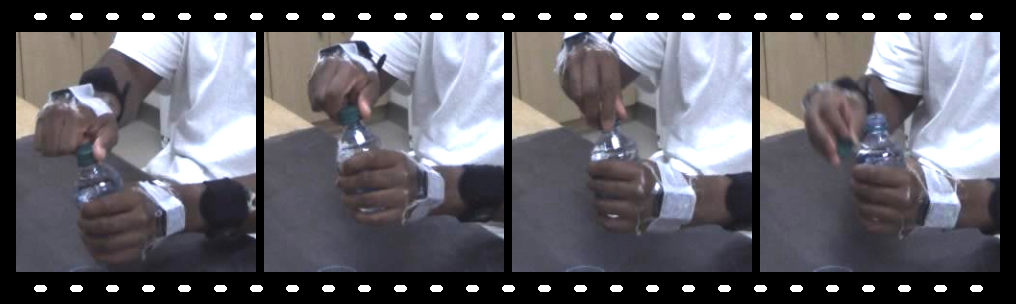

In [46]:
defaced = deface_video_frames(video_path, k=4, start_time=2, end_time=5)
print(defaced[0].shape)
film_strip = make_film_strip(defaced, global_bbox=(400, 350, 250, 250), alpha=1.3, beta=30, gamma=0.8)  #, alpha=1.2, beta=15, gamma=1.4)
Image.fromarray(film_strip)

# Overreliance on 2D semantics

In [9]:
def _is_overlap(interval_a, interval_b):
    a_start, a_end = interval_a
    b_start, b_end = interval_b
    return max(a_start, b_start) < min(a_end, b_end)


def label_path_to_answers(label_path, start_time, end_time, chunk_time):
    actions = PrimitiveLabelUtils.convert_labels_to_action_sequence(label_path)
    action_idx = 0

    num_chunks = int(np.ceil((end_time - start_time) / chunk_time))
    all_chunk_actions = []
    for i in range(num_chunks):
        chunk_start_time = start_time + i * chunk_time
        chunk_end_time = min(end_time, chunk_start_time + chunk_time)

        # Find all primitives that overlap with this chunk
        chunk_actions = []
        while action_idx < len(actions):
            action = actions[action_idx]
            action_start = action['start_time']
            action_end = action_start + action['duration']

            if _is_overlap((action_start, action_end), (chunk_start_time, chunk_end_time)):
                chunk_actions.append(action['action'])
                action_idx += 1
            elif action_end <= chunk_start_time:
                action_idx += 1
            else:
                break
        action_idx -= 1
        all_chunk_actions.append(chunk_actions)
    return all_chunk_actions


def convert_chunk_actions_to_contact(chunk_actions_list):
    contact_answers = ['transport', 'stabilize']
    non_contact_answers = ['idle', 'reach', 'reposition']

    for chunk_actions in chunk_actions_list:
        seen_contact = any(action in contact_answers for action in chunk_actions)
        seen_no_contact = any(action in non_contact_answers for action in chunk_actions)

        if seen_contact and seen_no_contact:
            yield "Unknown"
        elif seen_contact:
            yield "Yes"
        elif seen_no_contact:
            yield "No"
        else:
            raise ValueError("No valid actions found in chunk")

In [21]:
from PIL import Image, ImageDraw
import numpy as np

YES_NO_COLORS = {
    # Yes (Average of stabilize and transport)
    "Yes": (217, 140, 84),
    "Unknown": (0, 0, 0),
    # No (Dark Gray from the old PRIMITIVE_COLORS)
    "No": (169, 169, 169),
}

def draw_yes_no_comparison(predictions, gt_contact_answers, segment_width=40, bar_height=25, spacing=0, chunk_time=0.533):
    """
    Draws two horizontal bars comparing 'Yes'/'No' answers for Ground Truth 
    and Predictions, where each element is a segment of the bar.

    :param predictions: List of 'Yes' or 'No' strings for predictions.
    :param gt_contact_answers: List of 'Yes' or 'No' strings for ground truth.
    :param segment_width: Width (in pixels) for each 'Yes'/'No' segment.
    :param bar_height: Height (in pixels) for each timeline bar.
    :param spacing: Vertical spacing between the bars and image borders.
    :return: A PIL Image object.
    """
    
    # 1. Input Validation and Setup
    if len(predictions) != len(gt_contact_answers):
        raise ValueError("Prediction list and Ground Truth list must have the same length.")
    
    num_segments = len(predictions)
    img_width = num_segments * segment_width
    # Total height: Top margin + Bar 1 + Spacing + Bar 2 + Bottom margin + Label space
    img_height = (3 * spacing) + (2 * bar_height)
    
    img = Image.new('RGB', (img_width, img_height), 'white')
    draw = ImageDraw.Draw(img)

    # Y-coordinates for the bars
    gt_y_start = spacing
    pred_y_start = gt_y_start + bar_height + spacing
    
    # Text color for labels
    label_color = (0, 0, 0) # Black

    # --- Helper function to draw a single bar ---
    def draw_bar(answers, y_start):
        for i, answer in enumerate(answers):
            x1 = i * segment_width
            x2 = (i + 1) * segment_width
            
            # Determine color, defaulting to black if the answer is invalid
            color = YES_NO_COLORS.get(answer, (0, 0, 0))
            
            # Draw the colored segment
            draw.rectangle([x1, y_start, x2, y_start + bar_height], fill=color)
            
            # Draw segment border line
            draw.line([(x2, y_start), (x2, y_start + bar_height)], fill=(50, 50, 50), width=1)
            
        # Draw a border around the entire bar
        draw.rectangle([0, y_start, img_width-1, y_start + bar_height-1], outline=(0,0,0), width=1)

    # --- Draw the bars ---
    draw_bar(gt_contact_answers, gt_y_start)
    draw_bar(predictions, pred_y_start)

# --- Draw dashed chunk lines at segment boundaries ---
    dash_length = 5
    gap_length = 3
    
    # Iterate from the first boundary (after segment 0) up to the last boundary
    for i in range(1, num_segments):
        x_pos = i * segment_width
        
        # Draw the dashed line from the top of the top bar to the bottom of the bottom bar
        y = gt_y_start 
        y_end = pred_y_start + bar_height
        
        current_y = y
        while current_y < y_end:
            next_y = min(current_y + dash_length, y_end)
            
            draw.line([(x_pos, current_y), (x_pos, next_y)], 
                      fill=(50, 50, 50), # Use a darker gray for the lines
                      width=1)
            
            current_y += dash_length + gap_length

    # --- Add Labels (GT and Pred) ---
    # Position labels to the left of the drawing area for clarity
    draw.text((-40, gt_y_start + bar_height // 3), "GT", fill=label_color)
    draw.text((-40, pred_y_start + bar_height // 3), "Pred", fill=label_color)

    # Since the drawing starts at x=0, we'll shift the entire image content
    # to the right slightly so the labels are visible.
    final_width = img_width
    final_img = Image.new('RGB', (final_width, img_height), 'white')
    final_draw = ImageDraw.Draw(final_img)
    
    # Copy the content from the original image (the bars)
    final_img.paste(img, (0, 0)) 
    
    return final_img


In [ ]:
video_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00020/C00020_shelf right side1_1.mkv"
start_time, end_time = 0.0, 30.0  #14.0, 20.0
chunk_time = 0.533
time = start_time
predictions = []
while time < end_time:
    frames_rgb = load_frames_rgb(video_path, start_time=time, end_time=time + chunk_time)
    prompt = "Is the subject's right hand grasping the pink object? Answer 'Yes' or 'No' directly."
    ans = vlm.process_frames(frames_rgb, prompt=prompt)
    predictions.append(ans)
    time += chunk_time
label_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/rawVideoLabels/C00020/C00020_shelf right side1_1.csv"

Input:  /tmp/tmpp7iwy8gd/frame.jpg
Output: /tmp/tmpp7iwy8gd/frame_defaced.jpg
Input:  /tmp/tmp5zkck3ns/frame.jpg
Output: /tmp/tmp5zkck3ns/frame_defaced.jpg
Input:  /tmp/tmp0_cmmc6e/frame.jpg
Output: /tmp/tmp0_cmmc6e/frame_defaced.jpg
Input:  /tmp/tmph0xstbf8/frame.jpg
Output: /tmp/tmph0xstbf8/frame_defaced.jpg
Input:  /tmp/tmplhl05tsw/frame.jpg
Output: /tmp/tmplhl05tsw/frame_defaced.jpg
Input:  /tmp/tmp5xnh3bna/frame.jpg
Output: /tmp/tmp5xnh3bna/frame_defaced.jpg
Input:  /tmp/tmp70mx_yhg/frame.jpg
Output: /tmp/tmp70mx_yhg/frame_defaced.jpg
Input:  /tmp/tmp5bv8u37k/frame.jpg
Output: /tmp/tmp5bv8u37k/frame_defaced.jpg
(704, 1088, 3)


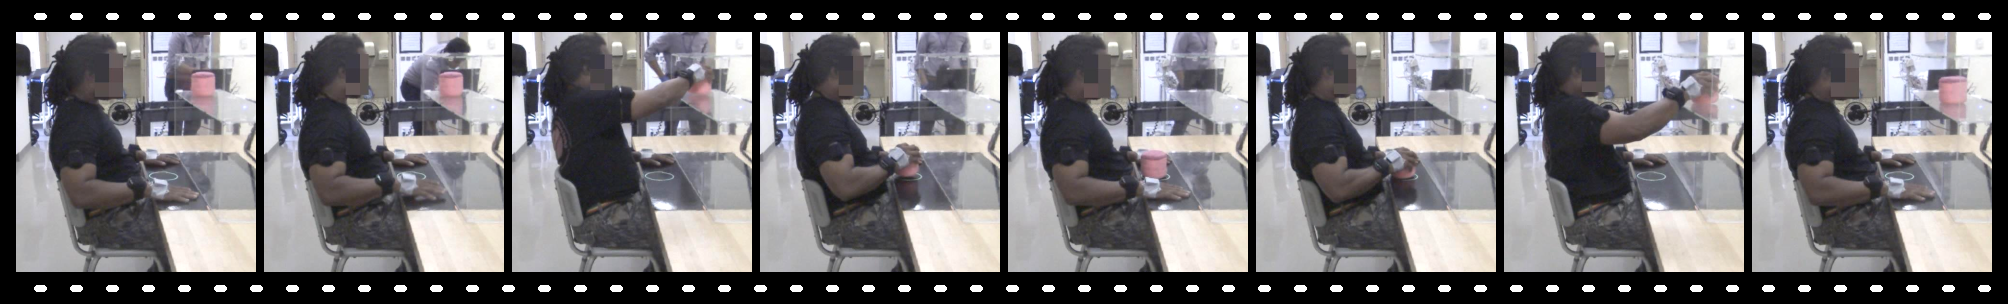

In [ ]:
video_path = "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoData/rawVideosADLsandFM/C00020/C00020_shelf right side1_1.mkv"
defaced = deface_video_frames(video_path, k=8, start_time=14*chunk_time, end_time=26*chunk_time)
print(defaced[0].shape)
film_strip = make_film_strip(defaced, global_bbox=(400, 150, 500, 500), alpha=1.2)  #, alpha=1.2, beta=15, gamma=1.4)
Image.fromarray(film_strip)

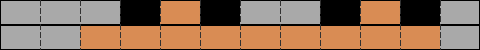

In [ ]:
gt_primitive_answers = label_path_to_answers(label_path, start_time, end_time, chunk_time)
gt_contact_answers = list(convert_chunk_actions_to_contact(gt_primitive_answers))
draw_yes_no_comparison(predictions[14:26], gt_contact_answers[14:26])

# Hallucination

Input:  /tmp/tmp_hlxhu3n/frame.jpg
Output: /tmp/tmp_hlxhu3n/frame_defaced.jpg
Input:  /tmp/tmp7ndeqjek/frame.jpg
Output: /tmp/tmp7ndeqjek/frame_defaced.jpg
Input:  /tmp/tmpprv1lq2g/frame.jpg
Output: /tmp/tmpprv1lq2g/frame_defaced.jpg
Input:  /tmp/tmpde05c951/frame.jpg
Output: /tmp/tmpde05c951/frame_defaced.jpg
Input:  /tmp/tmpf44zaz2g/frame.jpg
Output: /tmp/tmpf44zaz2g/frame_defaced.jpg
Input:  /tmp/tmphc7xemaz/frame.jpg
Output: /tmp/tmphc7xemaz/frame_defaced.jpg
(704, 1088, 3)


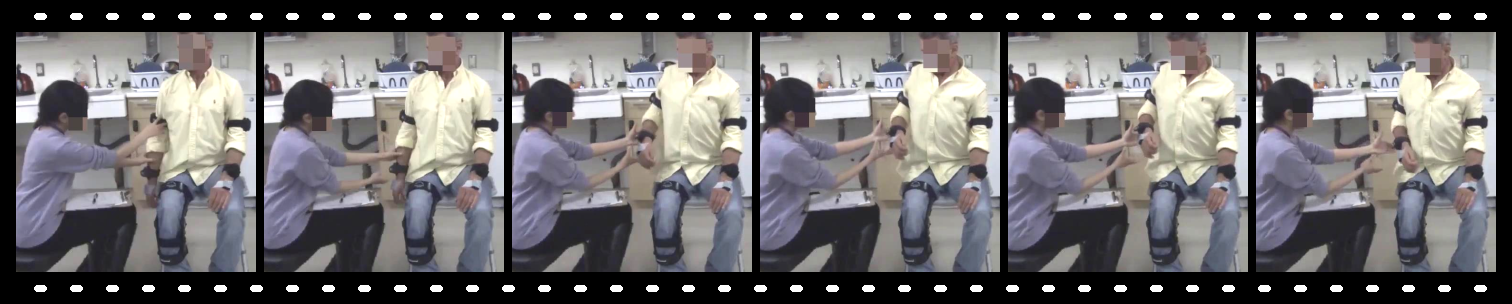

In [ ]:
video_path =  "/gpfs/data/schambralab/quantitativeRehabilitation/__data/VideoDataDerived/FMVideoClips/clippedVideos/S00031/S00031_FM13_A_F.mp4"
defaced = deface_video_frames(video_path, k=6)
print(defaced[0].shape)
film_strip = make_film_strip(defaced, global_bbox=(200,200,504,504), alpha=1.3, beta=25)  #, alpha=1.2, beta=15, gamma=1.4)
Image.fromarray(film_strip)

In [162]:
json_str = "{ \"question\": \"How well does the patient flex their shoulder to 90 degrees?\", \"response_instructions\": \"After noting your observations, end your reply with a single line exactly: FINAL_SCORE: <0|1|2>.\", \"instructions\": \"Task cue: 'Start with your arm straight down at your side with your thumb pointing forward. Keep your elbow straight as you raise your arm up to shoulder height in front of you.' We allow assistance to attain the starting position.\", \"scoring_criteria\": { \"0\": \"Cannot be performed. Patient cannot maintain the starting position, or deviates at the start. Deviations include a bend at the elbow, shoulder abduction, or forearm pronation.\", \"1\": \"Performed partially. Patient can raise their arm but not to 90 degrees, or deviates after starting. Deviations include a bend at the elbow, shoulder abduction, or forearm pronation.\", \"2\": \"Performed faultlessly. Patient can raise their arm to 90 degrees without any deviations.\" } }"

# Format it
import json
json_obj = json.loads(json_str)
# Pretty-print with indentation
pretty_json_str = json.dumps(json_obj, indent=4)
print(pretty_json_str)

{
    "question": "How well does the patient flex their shoulder to 90 degrees?",
    "response_instructions": "After noting your observations, end your reply with a single line exactly: FINAL_SCORE: <0|1|2>.",
    "instructions": "Task cue: 'Start with your arm straight down at your side with your thumb pointing forward. Keep your elbow straight as you raise your arm up to shoulder height in front of you.' We allow assistance to attain the starting position.",
    "scoring_criteria": {
        "0": "Cannot be performed. Patient cannot maintain the starting position, or deviates at the start. Deviations include a bend at the elbow, shoulder abduction, or forearm pronation.",
        "1": "Performed partially. Patient can raise their arm but not to 90 degrees, or deviates after starting. Deviations include a bend at the elbow, shoulder abduction, or forearm pronation.",
        "2": "Performed faultlessly. Patient can raise their arm to 90 degrees without any deviations."
    }
}
